# Tumor patch classification

This notebook reads what the pipeline recorded. It trains nothing and computes nothing. Run `python analysis/run_all.py` first.

The stages it presents are `src/s04_patches.py`, which places each segmentation on its image grid and cuts the patches, `src/s05_splits.py`, which assigns whole patients to the three parts, `src/s06_model.py`, which holds the network and trains it, and `src/s07_evaluate.py`, which scores it. Every figure below is shown under the function in `src/s08_figures.py` that drew it.

The task is to decide whether a 32 by 32 patch of an axial T1 post-contrast slice lies inside the tumor.

In [1]:
import inspect
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from IPython.display import Image, display

from src import config, s08_figures
from src.s99_utils import Metrics

pd.set_option("display.width", 110)
pd.set_option("display.max_rows", 60)

metrics = Metrics()


def table(name):
    return pd.read_csv(config.RESULTS / (name + ".csv"))


def source(obj):
    """One function of the pipeline, printed as it stands in src/.

    The source is printed and not returned as a rich display object, because a
    highlighted object carries a LaTeX and an HTML form of itself and a reader
    on the repository page is served whichever of the two that page prefers.
    Plain text renders the same everywhere.
    """
    print(inspect.getsource(obj).rstrip())


# Every figure is drawn by one function in src/s08_figures.py from a table in
# results/, so a figure and the prose beside it cannot disagree. Each figure is
# shown here under the function that drew it.
DRAWN_BY = {
    "fig01_scanner_inventory.png": s08_figures.fig_scanners,
    "fig02_series_descriptions.png": s08_figures.fig_series_types,
    "fig03_image_grids.png": s08_figures.fig_grids,
    "fig04_mask_alignment.png": s08_figures.fig_alignment,
    "fig05_patch_examples.png": s08_figures.fig_patches,
    "fig06_class_balance.png": s08_figures.fig_class_balance,
    "fig07_splits.png": s08_figures.fig_splits,
    "fig08_grid_search.png": s08_figures.fig_grid_search,
    "fig09_training_history.png": s08_figures.fig_history,
    "fig10_roc_test.png": s08_figures.fig_roc,
    "fig11_confusion_matrix.png": s08_figures.fig_confusion,
    "fig12_per_patient.png": s08_figures.fig_per_patient,
    "fig13_split_leakage.png": s08_figures.fig_leakage,
    "fig14_errors.png": s08_figures.fig_errors,
}


def figure(name):
    source(DRAWN_BY[name])
    display(Image(filename=str(config.FIGURES / name)))


## The patch set

Tumor occupies a small part of the brain, so patches sampled on a regular grid are overwhelmingly negative. Negatives are subsampled to a fixed ratio for each patient, and the rate before sampling is kept so that the design choice stays visible.

In [2]:
summary = table("patch_summary")
print("patches", int(metrics.number("patches_total")),
      "of which positive", int(metrics.number("patches_positive")))
print("median positive rate before sampling: {:.4f}".format(
      metrics.number("patches_natural_positive_rate_median")))
summary[["patient_id", "slices_with_tumor", "tumor_fraction_of_brain",
         "candidate_positive_patches", "natural_positive_rate",
         "patches_positive", "patches_negative"]].head(10)

patches 58788 of which positive 19596
median positive rate before sampling: 0.0186


,patient_id,slices_with_tumor,tumor_fraction_of_brain,candidate_positive_patches,natural_positive_rate,patches_positive,patches_negative
0,UPENN-GBM-00019,51,0.026330,608,0.020044,500,1000
1,UPENN-GBM-00020,50,0.013369,304,0.007673,304,608
2,UPENN-GBM-00032,74,0.051787,1846,0.043546,500,1000
3,UPENN-GBM-00048,83,0.061097,2055,0.058430,500,1000
4,UPENN-GBM-00049,50,0.017462,388,0.009861,388,776
5,UPENN-GBM-00050,33,0.004667,36,0.000851,36,72
6,UPENN-GBM-00062,60,0.025427,626,0.017909,500,1000
7,UPENN-GBM-00075,47,0.014733,280,0.008381,280,560
8,UPENN-GBM-00085,55,0.024520,640,0.018600,500,1000
9,UPENN-GBM-00101,68,0.031644,795,0.024402,500,1000


def fig_patches():
    X, y, patients, _ = load_patches()
    rng = np.random.default_rng(config.SEED)
    figure, axes = plt.subplots(4, 10, figsize=(8.4, 3.8))
    for row_index, (label, name) in enumerate([(1, "tumor"), (0, "non-tumor")]):
        pool = np.flatnonzero(y == label)
        picked = rng.choice(pool, 20, replace=False)
        for column, chosen in enumerate(picked):
            axis = axes[row_index * 2 + column // 10, column % 10]
            axis.imshow(X[chosen], cmap="gray", vmin=0, vmax=1)
            axis.axis("off")
            axis.grid(False)
            if column == 0:
                axis.set_title(name, loc="left", fontsize=8)
    figure.suptitle("Patches drawn from the labeled volumes", fontsize=9)
    return save(figure, "fig05_patch_examples.png")


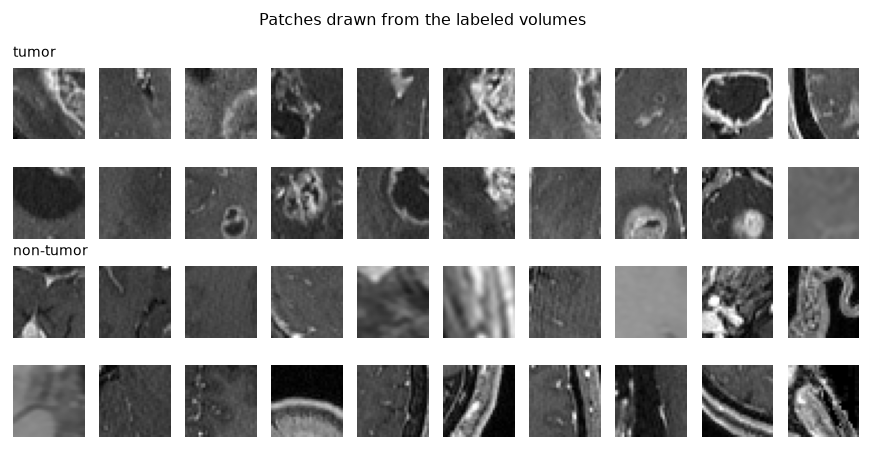

In [3]:
figure("fig05_patch_examples.png")

def fig_class_balance():
    rows = table("patch_summary")
    natural = [float(r["natural_positive_rate"]) for r in rows]
    total = [int(r["patches_positive"]) + int(r["patches_negative"]) for r in rows]
    figure, axes = plt.subplots(1, 2, figsize=(8, 3.2))
    axes[0].hist(np.array(natural) * 100, bins=15, color=BLUE)
    axes[0].set_xlabel("positive patches before sampling (percent)")
    axes[0].set_ylabel("patients")
    axes[0].set_title("Tumor is a small part of the brain")
    axes[1].bar(range(len(total)), sorted(total), color=ORANGE)
    axes[1].set_xlabel("patient, ordered by patch count")
    axes[1].set_ylabel("patches retained")
    axes[1].set_title("Patches contributed per patient")
    return save(figure, "fig06_class_balance.png")


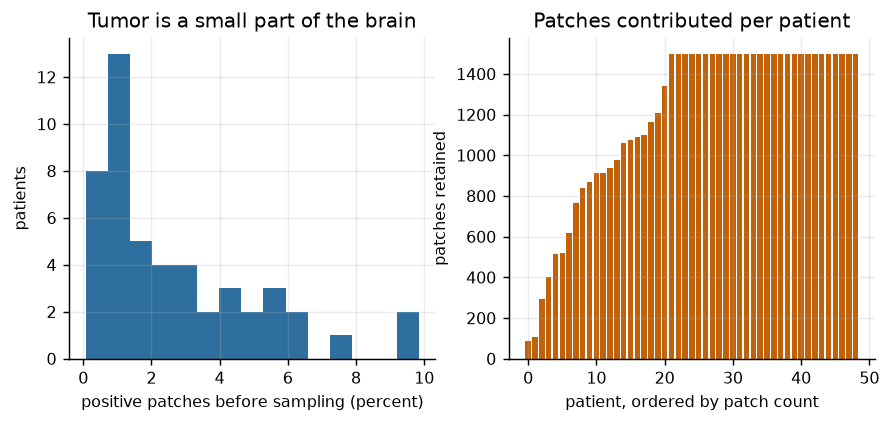

In [4]:
figure("fig06_class_balance.png")

## The split

Patches are cut on an eight pixel stride, so neighboring patches overlap by three quarters of their area. Splitting over patches would put near copies of the same tissue on both sides of the boundary. Whole patients are assigned instead.

In [5]:
splits = table("splits")
splits.groupby("split").agg(patients=("patient_id", "size"),
                            patches=("patches", "sum"),
                            positive=("positive", "sum"))

,patients,patches,positive
split,,,
test,13,14412,4804
train,29,38070,12690
validation,7,6306,2102


def fig_splits():
    rows = table("splits")
    order = {"train": 0, "validation": 1, "test": 2}
    rows.sort(key=lambda r: (order[r["split"]], r["patient_id"]))
    colors = {"train": BLUE, "validation": GRAY, "test": ORANGE}
    figure, axis = plt.subplots(figsize=(8, 3.2))
    axis.bar(range(len(rows)), [int(r["patches"]) for r in rows],
             color=[colors[r["split"]] for r in rows])
    axis.set_xlabel("patient")
    axis.set_ylabel("patches")
    axis.set_title("Patients are assigned whole to one part of the split")
    handles = [plt.Rectangle((0, 0), 1, 1, color=colors[k]) for k in order]
    axis.legend(handles, list(order), frameon=False)
    return save(figure, "fig07_splits.png")


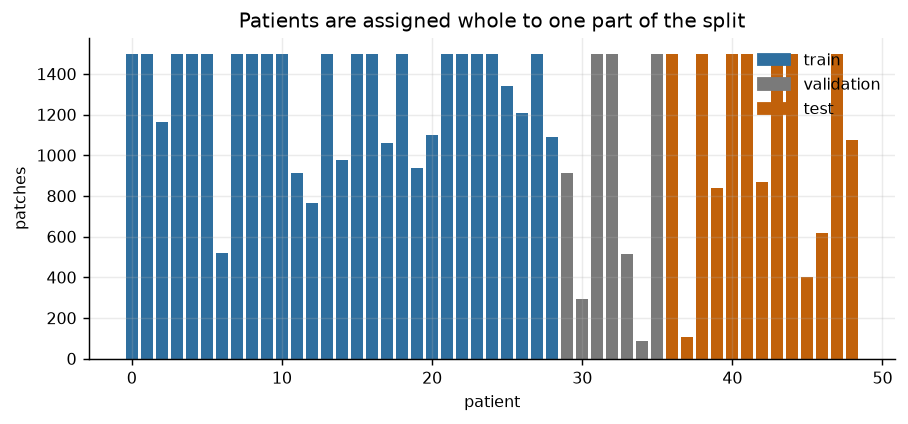

In [6]:
figure("fig07_splits.png")

## The network

The architecture, the training loop and the epoch selection are in
`src/s06_model.py`. The weights this notebook reports were written by stage 06;
nothing is trained here.

In [7]:
from src.s06_model import PatchCNN, select_epoch, train_model

source(PatchCNN)

class PatchCNN(nn.Module):
    """Conv(16) - Conv(16)+BN - Conv(64)+BN - Dense(64) - Dropout - sigmoid."""

    def __init__(self, dropout=0.5, size=config.PATCH_SIZE):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        flattened = 64 * (size // 8) ** 2
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal

In [8]:
source(train_model)

def train_model(X_train, y_train, X_validation, y_validation, learning_rate,
                dropout, epochs, seed=config.SEED, verbose=False):
    """Train for ``epochs`` epochs and return the weights of the best of them.

    The validation set is scored after every epoch on two quantities, ROC-AUC
    and cross-entropy loss, and the weights of the epoch that is best under
    ``config.EPOCH_SELECTION_MONITOR`` are copied and restored before the model
    is returned. Training is not cut short: every epoch runs, so the history is
    complete and the final-epoch weights survive in the returned selection
    record, where the caller that needs the size of the selection effect can
    score them.

    Neither the ROC-AUC nor the loss measurement draws from a random generator,
    because both run the network in evaluation mode under ``no_grad``, so the
    training trajectory is the one the previous run produced.
    """
    torch.manual_seed(seed)
    torch.use_deterministic_algorithm

In [9]:
source(select_epoch)

def select_epoch(history, monitor, mode):
    """Return the one-based epoch whose ``monitor`` column is most extreme."""
    improves = MONITOR_IMPROVES[mode]
    chosen = history[0]
    for row in history[1:]:
        if improves(row[monitor], chosen[monitor]):
            chosen = row
    return chosen["epoch"]


## Grid search

Every combination is scored on the validation patients, who appear in neither the training nor the test set.

In [10]:
table("model_grid")

,learning_rate,dropout,epochs,validation_roc_auc_final,validation_roc_auc_best,selected_epoch,train_loss_final,seconds,is_selected_configuration,selection_note
0,1.0,0.5,8,0.9524,0.9543,7,0.1520,148.6,1,selected: the largest of 4 configurations of a...
1,1.0,0.3,8,0.9300,0.9535,7,0.1243,180.2,0,not selected: the largest of 8 epochs of this ...
2,0.1,0.3,8,0.9128,0.9324,7,0.1664,158.9,0,not selected: the largest of 8 epochs of this ...
3,0.1,0.5,8,0.8934,0.9208,7,0.1943,149.3,0,not selected: the largest of 8 epochs of this ...


def fig_grid_search():
    rows = table("model_grid")
    dropouts = sorted({float(r["dropout"]) for r in rows})
    rates = sorted({float(r["learning_rate"]) for r in rows})
    figure, axis = plt.subplots(figsize=(5.4, 3.2))
    width = 0.35
    positions = np.arange(len(rates))
    for offset, dropout in enumerate(dropouts):
        values = [
            float(next(r for r in rows
                       if float(r["learning_rate"]) == rate
                       and float(r["dropout"]) == dropout)[GRID_SELECTION_CRITERION])
            for rate in rates
        ]
        axis.bar(positions + (offset - 0.5) * width, values, width,
                 label="dropout {:g}".format(dropout),
                 color=[BLUE, ORANGE][offset % 2])
    axis.set_xticks(positions)
    axis.set_xticklabels(["{:g}".format(r) for r in rates])
    axis.set_xlabel("Adadelta learning rate")
    axis.set_ylabel("validation ROC-AUC")
    axis.set_ylim(0.5, 1.0)
    # The bars are the criterion the configur

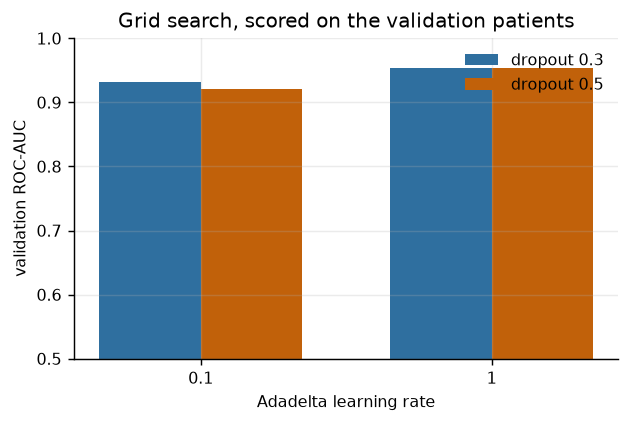

In [11]:
figure("fig08_grid_search.png")

def fig_history():
    """Training loss and validation ROC-AUC, with the retained epoch marked.

    The vertical line is the epoch whose weights the reported model uses. It is
    drawn because the curve alone does not say which point on it was kept, and
    the last epoch is not that point.
    """
    rows = table("training_history")
    epochs = [int(r["epoch"]) for r in rows]
    figure, axis = plt.subplots(figsize=(5.6, 3.2))
    axis.plot(epochs, [float(r["train_loss"]) for r in rows], color=BLUE,
              label="training loss")
    axis.set_xlabel("epoch")
    axis.set_ylabel("binary cross-entropy", color=BLUE)
    twin = axis.twinx()
    twin.plot(epochs, [float(r["validation_roc_auc"]) for r in rows], color=ORANGE,
              label="validation ROC-AUC")
    twin.set_ylabel("validation ROC-AUC", color=ORANGE)
    twin.grid(False)
    selected = next(int(r["epoch"]) for r in rows if int(r["is_selected_epoch"]))
    axis.axvline(selected, color=GRAY, linestyle="--", line

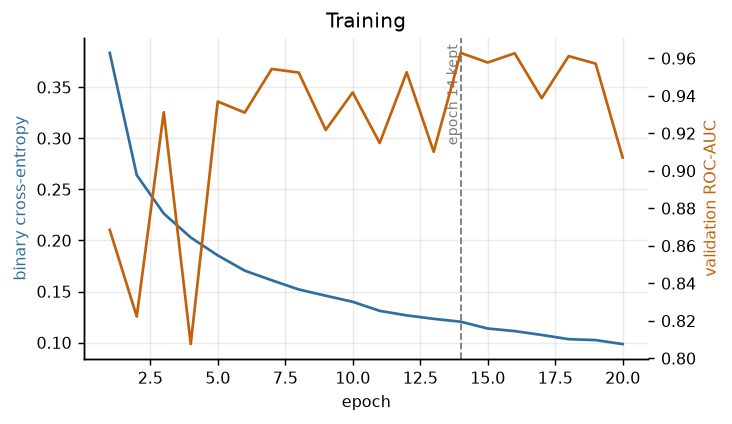

In [12]:
figure("fig09_training_history.png")

## Results on the held-out patients

In [13]:
rows = []
for part in ("train", "validation", "test"):
    rows.append({
        "split": part,
        "patches": int(metrics.number("eval_" + part + "_patches")),
        "roc_auc": metrics.number("eval_" + part + "_roc_auc"),
        "accuracy": metrics.number("eval_" + part + "_accuracy"),
    })
pd.DataFrame(rows)

,split,patches,roc_auc,accuracy
0,train,38070,0.9962,0.9612
1,validation,6306,0.9629,0.8957
2,test,14412,0.9864,0.9519


In [14]:
table("classification_report")

,split,class,took_part_in_epoch_selection,precision,recall,f1,support
0,train,non-tumor,no,0.9862,0.9552,0.9705,25380
1,train,tumor,no,0.9158,0.9732,0.9436,12690
2,validation,non-tumor,yes: the retained epoch maximizes this split's...,0.9256,0.9172,0.9214,4204
3,validation,tumor,yes: the retained epoch maximizes this split's...,0.8374,0.8525,0.8449,2102
4,test,non-tumor,no,0.9464,0.9836,0.9646,9608
5,test,tumor,no,0.9643,0.8886,0.9249,4804


def fig_roc():
    metrics = Metrics()
    rows = table("roc_test")
    fpr = [float(r["false_positive_rate"]) for r in rows]
    tpr = [float(r["true_positive_rate"]) for r in rows]
    figure, axis = plt.subplots(figsize=(4.4, 4.0))
    # The interval comes from resampling the thirteen test patients, so the label
    # carries the room the point estimate actually has.
    axis.plot(fpr, tpr, color=BLUE,
              label="test, AUC {:.3f}\n{:.0f} percent interval {:.3f} to "
                    "{:.3f}".format(
                        metrics.number("eval_test_roc_auc"),
                        100 * metrics.number("eval_test_roc_auc_bootstrap_interval"),
                        metrics.number("eval_test_roc_auc_bootstrap_low"),
                        metrics.number("eval_test_roc_auc_bootstrap_high")))
    axis.plot([0, 1], [0, 1], color=GRAY, linestyle="--", linewidth=1)
    axis.set_xlabel("false positive rate")
    axis.set_ylabel("true positive rate")
    axis.set_title("Held

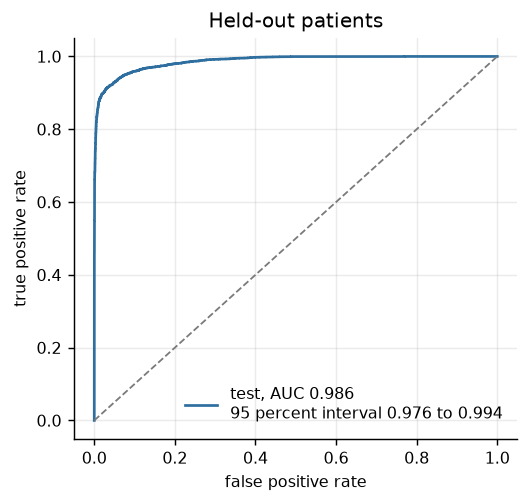

In [15]:
figure("fig10_roc_test.png")

In [16]:
confusion = table("confusion_matrix")
confusion[confusion["split"] == "test"].pivot(
    index="actual", columns="predicted", values="count")

predicted,non-tumor,tumor
actual,,
non-tumor,9450,158
tumor,535,4269


def fig_confusion():
    rows = [r for r in table("confusion_matrix") if r["split"] == "test"]
    names = ["non-tumor", "tumor"]
    matrix = np.zeros((2, 2), dtype=int)
    for row in rows:
        matrix[names.index(row["actual"]), names.index(row["predicted"])] = int(row["count"])
    figure, axis = plt.subplots(figsize=(4.0, 3.6))
    axis.imshow(matrix, cmap="Blues")
    axis.grid(False)
    for i in range(2):
        for j in range(2):
            axis.text(j, i, str(matrix[i, j]), ha="center", va="center",
                      color="white" if matrix[i, j] > matrix.max() / 2 else "black")
    axis.set_xticks([0, 1], names)
    axis.set_yticks([0, 1], names)
    axis.set_xlabel("predicted")
    axis.set_ylabel("actual")
    axis.set_title("Test confusion matrix at threshold 0.5")
    return save(figure, "fig11_confusion_matrix.png")


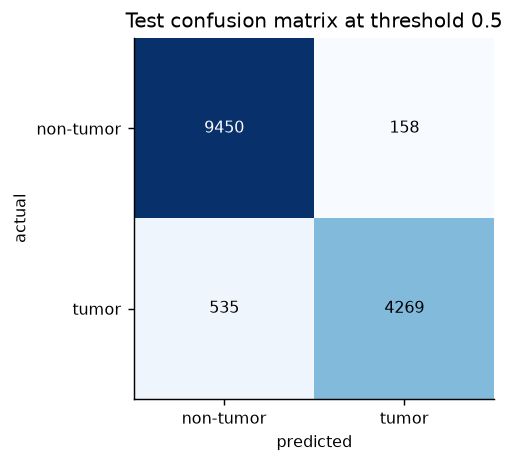

In [17]:
figure("fig11_confusion_matrix.png")

## Where the model fails

A score pooled over patches hides a model that works on most patients and fails on a few, so the test set is broken down by patient.

In [18]:
table("per_patient_test").sort_values("roc_auc").head(10)

,patient_id,patches,positive_rate_fixed_by_sampling,natural_positive_rate,roc_auc,accuracy,false_positive,false_negative
2,UPENN-GBM-00062,1500,0.3333,0.017909,0.9565,0.8227,9,257
3,UPENN-GBM-00075,840,0.3333,0.008381,0.9822,0.9333,5,51
11,UPENN-GBM-00421,1500,0.3333,0.052383,0.9851,0.9573,22,42
8,UPENN-GBM-00365,1500,0.3333,0.030280,0.9853,0.9493,24,52
6,UPENN-GBM-00264,870,0.3333,0.009620,0.9892,0.9425,6,44
0,UPENN-GBM-00032,1500,0.3333,0.043546,0.9895,0.9633,26,29
4,UPENN-GBM-00142,1500,0.3333,0.044862,0.9942,0.9733,15,25
7,UPENN-GBM-00334,1500,0.3333,0.048426,0.9964,0.9827,16,10
5,UPENN-GBM-00226,1500,0.3333,0.020702,0.9976,0.9820,14,13
12,UPENN-GBM-00587,1077,0.3333,0.009989,0.9980,0.9842,10,7


def fig_per_patient():
    rows = [r for r in table("per_patient_test") if r["roc_auc"] != ""]
    rows.sort(key=lambda r: float(r["roc_auc"]))
    figure, axis = plt.subplots(figsize=(7, 3.2))
    axis.bar([r["patient_id"][-5:] for r in rows],
             [float(r["roc_auc"]) for r in rows], color=BLUE)
    axis.axhline(0.5, color=GRAY, linestyle="--", linewidth=1)
    axis.set_ylim(0, 1.02)
    axis.set_ylabel("ROC-AUC")
    axis.set_xlabel("test patient")
    axis.tick_params(axis="x", rotation=90, labelsize=6)
    axis.set_title("Performance is not uniform across held-out patients")
    return save(figure, "fig12_per_patient.png")


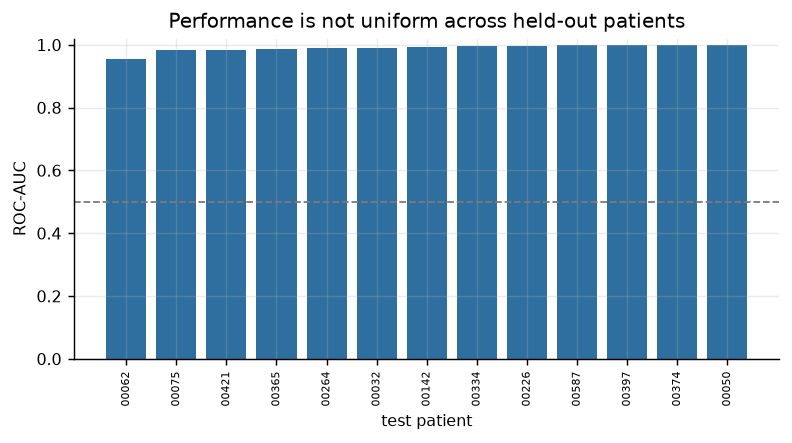

In [19]:
figure("fig12_per_patient.png")

def fig_errors():
    X, y, patients, _ = load_patches()
    patient_split, _ = load_splits()
    scores = predict(load_model(), X)
    test = patient_split == "test"
    predicted = (scores >= 0.5).astype(int)
    false_positive = np.flatnonzero(test & (predicted == 1) & (y == 0))
    false_negative = np.flatnonzero(test & (predicted == 0) & (y == 1))
    rng = np.random.default_rng(config.SEED)

    figure, axes = plt.subplots(2, 8, figsize=(8.4, 2.6))
    for row_index, (pool, name) in enumerate(
            [(false_positive, "false positive"), (false_negative, "false negative")]):
        picked = rng.choice(pool, min(8, len(pool)), replace=False) if len(pool) else []
        for column in range(8):
            axis = axes[row_index, column]
            axis.axis("off")
            axis.grid(False)
            if column < len(picked):
                axis.imshow(X[picked[column]], cmap="gray", vmin=0, vmax=1)
            if column == 0:
                axis.set_title(name, loc="lef

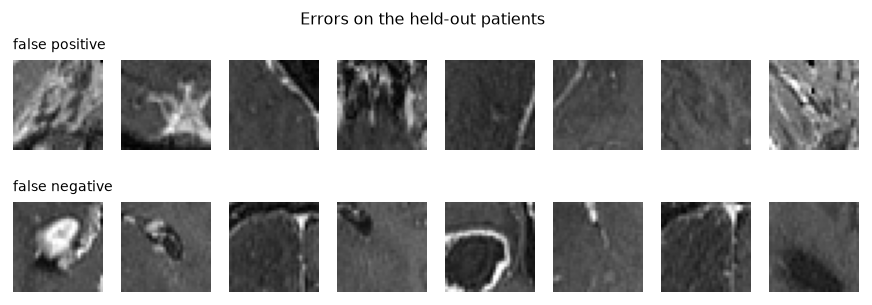

In [20]:
figure("fig14_errors.png")

## What splitting over patches would have reported

The same architecture and the same hyperparameters, trained on a partition that shuffles patches instead of patients.

In [21]:
pd.Series({
    "test ROC-AUC, split by patient":
        metrics.number("leakage_test_roc_auc_patient_split"),
    "test ROC-AUC, split by patch":
        metrics.number("leakage_test_roc_auc_patch_split"),
    "difference, primary seed":
        metrics.number("leakage_roc_auc_inflation_primary_seed"),
    "difference, mean over {} seeds".format(
        metrics.get("leakage_roc_auc_inflation_seed_count")):
        metrics.number("leakage_roc_auc_inflation_seed_mean"),
}).to_frame("value")

,value
"test ROC-AUC, split by patient",0.9864
"test ROC-AUC, split by patch",0.9907
"difference, primary seed",0.0043
"difference, mean over 3 seeds",0.0407


def fig_leakage():
    """The two partitions at the primary seed, drawn over the range across seeds.

    The bars are the primary-seed scores the text quotes. The points are the
    scores at every seed in ``config.SEED_LIST``, so that the difference
    between the bars is read against the spread the seed alone produces and not
    as a fixed quantity.
    """
    metrics = Metrics()
    honest = metrics.number("leakage_test_roc_auc_patient_split")
    leaky = metrics.number("leakage_test_roc_auc_patch_split")
    variance = table("seed_variance")
    labels = ["split by patient", "split by patch"]
    per_seed = [
        [float(r["test_roc_auc"]) for r in variance if r["split_unit"] == part]
        for part in ("patient", "patch")
    ]
    figure, axis = plt.subplots(figsize=(4.8, 3.4))
    axis.bar(labels, [honest, leaky], color=[BLUE, ORANGE])
    for position, values in enumerate(per_seed):
        axis.plot([position] * len(values), values, "o", color=GRAY,
                  

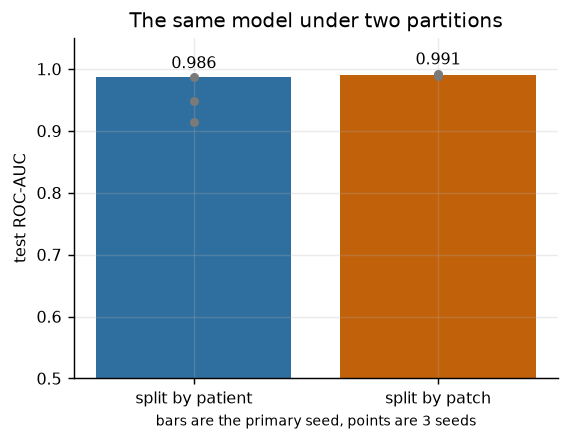

In [22]:
figure("fig13_split_leakage.png")

## The record these results were read from

Every number and every figure above was read from `results/` and `figures/` as the pipeline last wrote them. The signature below is a digest of the recorded quantities that a re-run reproduces exactly. Gate 07 recomputes it from `results/metrics.csv` and compares, so a notebook left standing against an older record fails a gate instead of going on being read.


In [23]:
from src.s99_utils import record_signature

# One string in one call, so the label and the digest cannot be split
# across two stream messages by the kernel.
print("{} {}".format(config.RECORD_SIGNATURE_LABEL, record_signature()))


record signature 57545bc7f42d7587
